# Benchmark: pykarambola vs C++ karambola — AdrenalMNIST3D

Addresses issues [#19](https://github.com/Pitt-IshiharaLab/pykarambola/issues/19) (runtime) and
[#20](https://github.com/Pitt-IshiharaLab/pykarambola/issues/20) (numerical accuracy).

**Dataset:** AdrenalMNIST3D — 1,584 adrenal gland meshes (train 1,188 / val 98 / test 298),
two resolutions (28³ and 64³ voxels), center-of-mass aligned to origin.

**What this notebook does:**
1. Parses pre-computed C++ karambola result folders into CSVs
2. Runs pykarambola on the same `.off` meshes (timed)
3. Reports wall-clock times (issue #19)
4. Plots numerical agreement figures (issue #20)

## Environment

In [46]:
import numpy as np
import pandas as pd
import os
import re
import glob
import time
import platform
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn

import pykarambola

In [47]:
# pykarambola version
print(f"pykarambola version : {pykarambola.__version__}")

# Machine details
print(f"Python              : {platform.python_version()}")
print(f"OS                  : {platform.system()} {platform.release()}")
print(f"Machine             : {platform.machine()}")
try:
    chip = subprocess.run(
        ['sysctl', '-n', 'machdep.cpu.brand_string'],
        capture_output=True, text=True
    ).stdout.strip()
    if not chip:
        chip = platform.processor()
except Exception:
    chip = platform.processor()
print(f"Chip                : {chip}")
print(f"Logical cores       : {os.cpu_count()}")
try:
    phys = subprocess.run(
        ['sysctl', '-n', 'hw.physicalcpu'],
        capture_output=True, text=True
    ).stdout.strip()
    print(f"Physical cores      : {phys}")
except Exception:
    pass

pykarambola version : 0.1.0
Python              : 3.11.14
OS                  : Darwin 24.6.0
Machine             : x86_64
Chip                : Apple M1 Pro
Logical cores       : 10
Physical cores      : 10


## Configuration

In [ ]:
assert Path.cwd().name == 'notebooks', (
    f"Expected CWD to be 'paper/notebooks/', got: {Path.cwd()}\n"
    "Please launch Jupyter from the paper/notebooks/ directory."
)

CHANNELS   = ['28', '64']
SPLITS     = ['train', 'validation', 'test']
SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']
VECTOR_KEYS = ['w010', 'w110', 'w210', 'w310']
TENSOR_KEYS = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']

# Input meshes
BASE_MESH_PATH = '../../dataset/medmnist_benchmarking/adrenal3d'

# C++ karambola result folders and log
BASE_KARA_PATH = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d'
_logs  = sorted(glob.glob(os.path.join(BASE_KARA_PATH, 'run_karambola_*.log')))
KARA_LOG = _logs[-1] if _logs else None
if KARA_LOG:
    print(f"Using karambola log: {os.path.basename(KARA_LOG)}")
else:
    print("Warning: no karambola log file found in", BASE_KARA_PATH)

# Where to write CSVs and figures
FIGURES_PATH   = 'results'
os.makedirs(FIGURES_PATH, exist_ok=True)

# Pairs where max(|k|, |py|) < ABS_THRESHOLD are "near-zero": both values are
# effectively zero at the scale of the data and the relative-error metric is
# not meaningful there.  They are excluded from relative-error statistics and
# reported separately via n_near_zero / mean_abs_err_nz in error_summary().
ABS_THRESHOLD = 1e-6

## Helper functions

In [49]:
def calculate_beta(eigenvalues):
    """Anisotropy scalar: min(|λ|) / max(|λ|)."""
    abs_eigs = np.abs(eigenvalues)
    mx = abs_eigs.max()
    return float(abs_eigs.min() / mx) if mx > 1e-12 else float('nan')


def round_floats(df, decimals=5):
    float_cols = df.select_dtypes(include='float').columns
    df[float_cols] = df[float_cols].round(decimals)
    df[float_cols] = df[float_cols].replace(0.0, 1e-5)
    return df


def drop_symmetric_duplicates(df):
    """Drop redundant off-diagonal symmetric columns (e.g. w020_10 when w020_01 == w020_10)."""
    pattern = re.compile(r'^(w\d{3})_(\d)(\d)$')
    seen, to_drop = set(), []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            sym = f'{tensor}_{j}{i}'
            if i != j and sym in df.columns and (col, sym) not in seen and (sym, col) not in seen:
                seen.add((col, sym))
                if (df[col] == df[sym]).all():
                    to_drop.append(sym)
    return df.drop(columns=to_drop)


def parse_filename(fname):
    """Parse '{split}_image_{num}_label_{label}' folder/file names.
    Returns (split, image_num_str, label_int) or None if not matched.
    """
    m = re.match(r'^(\w+?)_image_(\d+)_label_(\d+)$', fname)
    if m:
        return m.group(1), m.group(2), int(m.group(3))
    return None


def parse_karambola_folder(folder_path):
    """Read all karambola output files from a single mesh result folder.
    Returns a dict of raw values or None if files are missing.
    """
    data = {
        'w000': None, 'w100': None, 'w200': None, 'w300': None,
        'w010': [None]*3, 'w110': [None]*3, 'w210': [None]*3, 'w310': [None]*3,
    }
    for t in TENSOR_KEYS:
        data[t] = [[None]*3 for _ in range(3)]
        data[f'{t}_eig'] = [None]*3

    # Scalars
    fp = os.path.join(folder_path, 'w000_w100_w200_w300')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 2 and cols[2] in data:
                    data[cols[2]] = float(cols[1])

    # Vectors
    fp = os.path.join(folder_path, 'w010_w110_w210_w310')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 4 and cols[4] in data:
                    data[cols[4]] = [float(cols[1]), float(cols[2]), float(cols[3])]

    # Rank-2 tensors
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, t)
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#'): continue
                    cols = line.split()
                    if len(cols) > 10 and cols[10] == t:
                        data[t] = [
                            [float(cols[1]), float(cols[2]), float(cols[3])],
                            [float(cols[4]), float(cols[5]), float(cols[6])],
                            [float(cols[7]), float(cols[8]), float(cols[9])],
                        ]

    # Eigensystems
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, f'{t}_eigsys')
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#') or 'ALL' not in line: continue
                    parts = line.split()
                    ev = sorted([float(parts[1]), float(parts[5]), float(parts[9])])
                    data[f'{t}_eig'] = ev
    return data


def build_row(data, image_num, label, split):
    """Flatten a parse_karambola_folder result dict into a flat record dict."""
    row = {'image_num': image_num, 'label': label, 'subfolder': split}
    for k in SCALAR_KEYS:
        row[k] = data[k]
    for vk in VECTOR_KEYS:
        for i in range(3):
            row[f'{vk}_{i}'] = data[vk][i]
    for tk in TENSOR_KEYS:
        for i in range(3):
            for j in range(3):
                row[f'{tk}_{i}{j}'] = data[tk][i][j]
        eigs = np.array(data[f'{tk}_eig'], dtype=float)
        row[f'beta_{tk}'] = calculate_beta(eigs)
        for n, ev in enumerate(eigs, 1):
            row[f'{tk}_EVal{n}'] = ev
    return row

## Parse C++ karambola results

In [50]:
kara_times = {}

for channel in CHANNELS:
    kara_path = os.path.join(BASE_KARA_PATH, f'adrenal3d_{channel}')

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(kara_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        folders = [d for d in os.listdir(split_path)
                   if os.path.isdir(os.path.join(split_path, d))]

        n_parsed = 0
        for folder_name in folders:
            parsed = parse_filename(folder_name)
            if parsed is None:
                continue   # skip old-format folders
            _, image_num, label = parsed
            folder_path = os.path.join(split_path, folder_name)
            data = parse_karambola_folder(folder_path)
            records.append(build_row(data, image_num, label, split))
            n_parsed += 1

        print(f'  adrenal3d_{channel} / {split}: {n_parsed} folders parsed')

    elapsed = time.perf_counter() - t0
    kara_times[channel] = elapsed

    df_k = pd.DataFrame(records)
    # df_k = round_floats(df_k)
    df_k = drop_symmetric_duplicates(df_k)

    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv')
    df_k.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_k)} rows → {csv_path}')

    print(f'  Parse time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 folders parsed
  adrenal3d_28 / validation: 98 folders parsed
  adrenal3d_28 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_28_karambola.csv
  Parse time: 2.4 s

  adrenal3d_64 / train: 1188 folders parsed
  adrenal3d_64 / validation: 98 folders parsed
  adrenal3d_64 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_64_karambola.csv
  Parse time: 2.5 s



In [51]:
# Parse C++ karambola wall-clock times from the run log
kara_log_times = {}   # channel -> total seconds (C++ compute time)
kara_split_times = {} # channel -> {split -> seconds}

with open(KARA_LOG) as f:
    current_channel = None
    for line in f:
        line = line.strip()
        # Track current resolution block
        m = re.match(r'^Resolution:\s+adrenal3d_(\d+)', line)
        if m:
            current_channel = m.group(1)
            kara_split_times[current_channel] = {}
            continue
        # Per-split time
        m = re.match(r'^Time for adrenal3d_\d+/(\w+):\s+(\d+)\s+seconds', line)
        if m and current_channel:
            kara_split_times[current_channel][m.group(1)] = int(m.group(2))
            continue
        # Total per resolution
        m = re.match(r'^Total time for adrenal3d_(\d+):\s+(\d+)\s+seconds', line)
        if m:
            kara_log_times[m.group(1)] = int(m.group(2))

print(f"C++ karambola runtimes (from log: {os.path.basename(KARA_LOG)})")
for ch in CHANNELS:
    splits = kara_split_times.get(ch, {})
    total  = kara_log_times.get(ch, 'N/A')
    print(f"  adrenal3d_{ch}: train={splits.get('train','?')}s  "
          f"validation={splits.get('validation','?')}s  "
          f"test={splits.get('test','?')}s  →  total={total}s")

C++ karambola runtimes (from log: run_karambola_adrenal_3d_2026-03-05_16-22-06.log)
  adrenal3d_28: train=69s  validation=6s  test=17s  →  total=92s
  adrenal3d_64: train=165s  validation=14s  test=42s  →  total=221s


## Run pykarambola

In [52]:
pyk_times = {}

for channel in CHANNELS:
    mesh_path = os.path.join(BASE_MESH_PATH, f'adrenal3d_{channel}')

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(mesh_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        files = glob.glob(os.path.join(split_path, '*.off'))
        print(f'  adrenal3d_{channel} / {split}: {len(files)} meshes')

        for fpath in files:
            fname = os.path.splitext(os.path.basename(fpath))[0]
            parsed = parse_filename(fname)
            if parsed is None:
                print(f'    [skip] unrecognised filename: {fname}')
                continue
            _, image_num, label = parsed

            tri = pykarambola.parse_off_file(fpath)
            nv, nt = tri.n_vertices(), tri.n_triangles()
            verts = np.array([tri.get_pos_of_vertex(i) for i in range(nv)], dtype=np.float64)
            faces = np.array(
                [[tri.ith_vertex_of_triangle(j, i) for i in range(3)] for j in range(nt)],
                dtype=np.int64,
            )
            result = pykarambola.minkowski_tensors(verts, faces)

            row = {'image_num': image_num, 'label': label, 'subfolder': split}
            for k in SCALAR_KEYS:
                row[k] = result[k]
            for vk in VECTOR_KEYS:
                for i in range(3):
                    row[f'{vk}_{i}'] = result[vk][i]
            for tk in TENSOR_KEYS:
                mat = result[tk]
                for i in range(3):
                    for j in range(3):
                        row[f'{tk}_{i}{j}'] = mat[i, j]
                eigvals = result[f'{tk}_eigvals']
                row[f'beta_{tk}'] = calculate_beta(eigvals)
                for n, ev in enumerate(sorted(eigvals), 1):
                    row[f'{tk}_EVal{n}'] = ev
            records.append(row)

    elapsed = time.perf_counter() - t0
    pyk_times[channel] = elapsed

    df_py = pd.DataFrame(records)
    df_py = drop_symmetric_duplicates(df_py)
    # df_py = round_floats(df_py)

    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv')
    df_py.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_py)} rows → {csv_path}')

    print(f'  Run time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 meshes
  adrenal3d_28 / validation: 98 meshes
  adrenal3d_28 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_28_pykarambola.csv
  Run time: 22.2 s

  adrenal3d_64 / train: 1188 meshes
  adrenal3d_64 / validation: 98 meshes
  adrenal3d_64 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_64_pykarambola.csv
  Run time: 111.9 s



## Runtime comparison (issue #19)

In [53]:
print("Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)")
print(f"{'Resolution':<16} {'C++ karambola':>18} {'pykarambola':>16} {'speedup':>10}")
print('-' * 64)

for ch in CHANNELS:
    k_t  = kara_log_times.get(ch, float('nan'))
    py_t = pyk_times.get(ch, float('nan'))
    speedup = k_t / py_t if py_t > 0 else float('nan')
    print(f"adrenal3d_{ch:<6}  {k_t:>14} s  {py_t:>12.1f} s  {speedup:>8.1f}×")

total_k  = sum(kara_log_times.values())
total_py = sum(pyk_times.values())
print('-' * 64)
print(f"{'Total':<16}  {total_k:>14} s  {total_py:>12.1f} s  {total_k/total_py:>8.1f}×")
print()
print(f"Log file: {os.path.basename(KARA_LOG)}")
print()
print("Note: C++ karambola time is total wall-clock time including I/O")
print("      (one output folder per mesh, written sequentially).")
print("      pykarambola time is pure Python compute (no file output).")

Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)
Resolution            C++ karambola      pykarambola    speedup
----------------------------------------------------------------
adrenal3d_28                  92 s          22.2 s       4.1×
adrenal3d_64                 221 s         111.9 s       2.0×
----------------------------------------------------------------
Total                        313 s         134.1 s       2.3×

Log file: run_karambola_adrenal_3d_2026-03-05_16-22-06.log

Note: C++ karambola time is total wall-clock time including I/O
      (one output folder per mesh, written sequentially).
      pykarambola time is pure Python compute (no file output).


## Numerical accuracy (issue #20)

Load the CSVs, merge on mesh identity, and compute relative errors.
Figures produced:
1. Scatter plots — pyk vs karambola for scalar functionals (w000, w100, w200, w300)
2. Bar chart — mean relative error per functional
3. Summary table — max and mean relative error per functional
4. Heatmap — mean relative error per mesh × feature

In [54]:
merged = {}

for channel in CHANNELS:
    df_k  = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_py = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    df_m = df_k.merge(df_py, on=['image_num', 'label', 'subfolder'],
                      suffixes=('_k', '_py'))
    merged[channel] = df_m
    print(f'adrenal3d_{channel}: {len(df_m)} matched rows')

adrenal3d_28: 1584 matched rows
adrenal3d_64: 1584 matched rows


> **Note (current results):** Values are compared without any additional rounding beyond the 5-decimal
> `round_floats` pass applied during CSV generation.
> pykarambola outputs are on the order of **~1e+12**, while C++ karambola measures reach up to **~1e+16**.
> The relative-error metric normalises by the karambola value, so the scale difference does not inflate
> error percentages, but it is worth noting for future normalisation or pre-processing steps.

In [ ]:
def relative_error_series(df_m, col, abs_threshold=ABS_THRESHOLD):
    """Per-row relative error (%) between _k and _py columns.

    Returns NaN for pairs where max(|k|, |py|) < abs_threshold — both values
    are effectively zero at the scale of the data and the relative-error
    metric is not meaningful there.
    """
    k  = df_m[f'{col}_k']
    py = df_m[f'{col}_py']
    denom = np.maximum(k.abs(), py.abs())
    rel_err = (k - py).abs() / denom * 100
    rel_err[denom < abs_threshold] = np.nan
    return rel_err


def error_summary(df_m, cols, abs_threshold=ABS_THRESHOLD):
    """DataFrame with mean/max relative error per column, plus near-zero diagnostics.

    Near-zero pairs (max(|k|, |py|) < abs_threshold) are excluded from the
    relative-error statistics.  Their count and mean absolute error are
    reported in n_near_zero / mean_abs_err_nz to confirm machine-precision
    agreement.
    """
    rows = []
    for col in cols:
        k  = df_m[f'{col}_k']
        py = df_m[f'{col}_py']
        near_zero = np.maximum(k.abs(), py.abs()) < abs_threshold
        err = relative_error_series(df_m, col, abs_threshold)
        abs_err_nz = (k - py).abs()[near_zero]
        rows.append({
            'feature':         col,
            'mean_rel_err_%':  err.mean(),   # pandas mean() skips NaN by default
            'max_rel_err_%':   err.max(),    # pandas max() skips NaN by default
            'n_near_zero':     int(near_zero.sum()),
            'mean_abs_err_nz': float(abs_err_nz.mean()) if near_zero.any() else float('nan'),
        })
    return pd.DataFrame(rows).set_index('feature')

### Figure 1 — Scatter: pykarambola vs C++ karambola (scalar functionals)

Saved → results/scatter_all_features_28.pdf


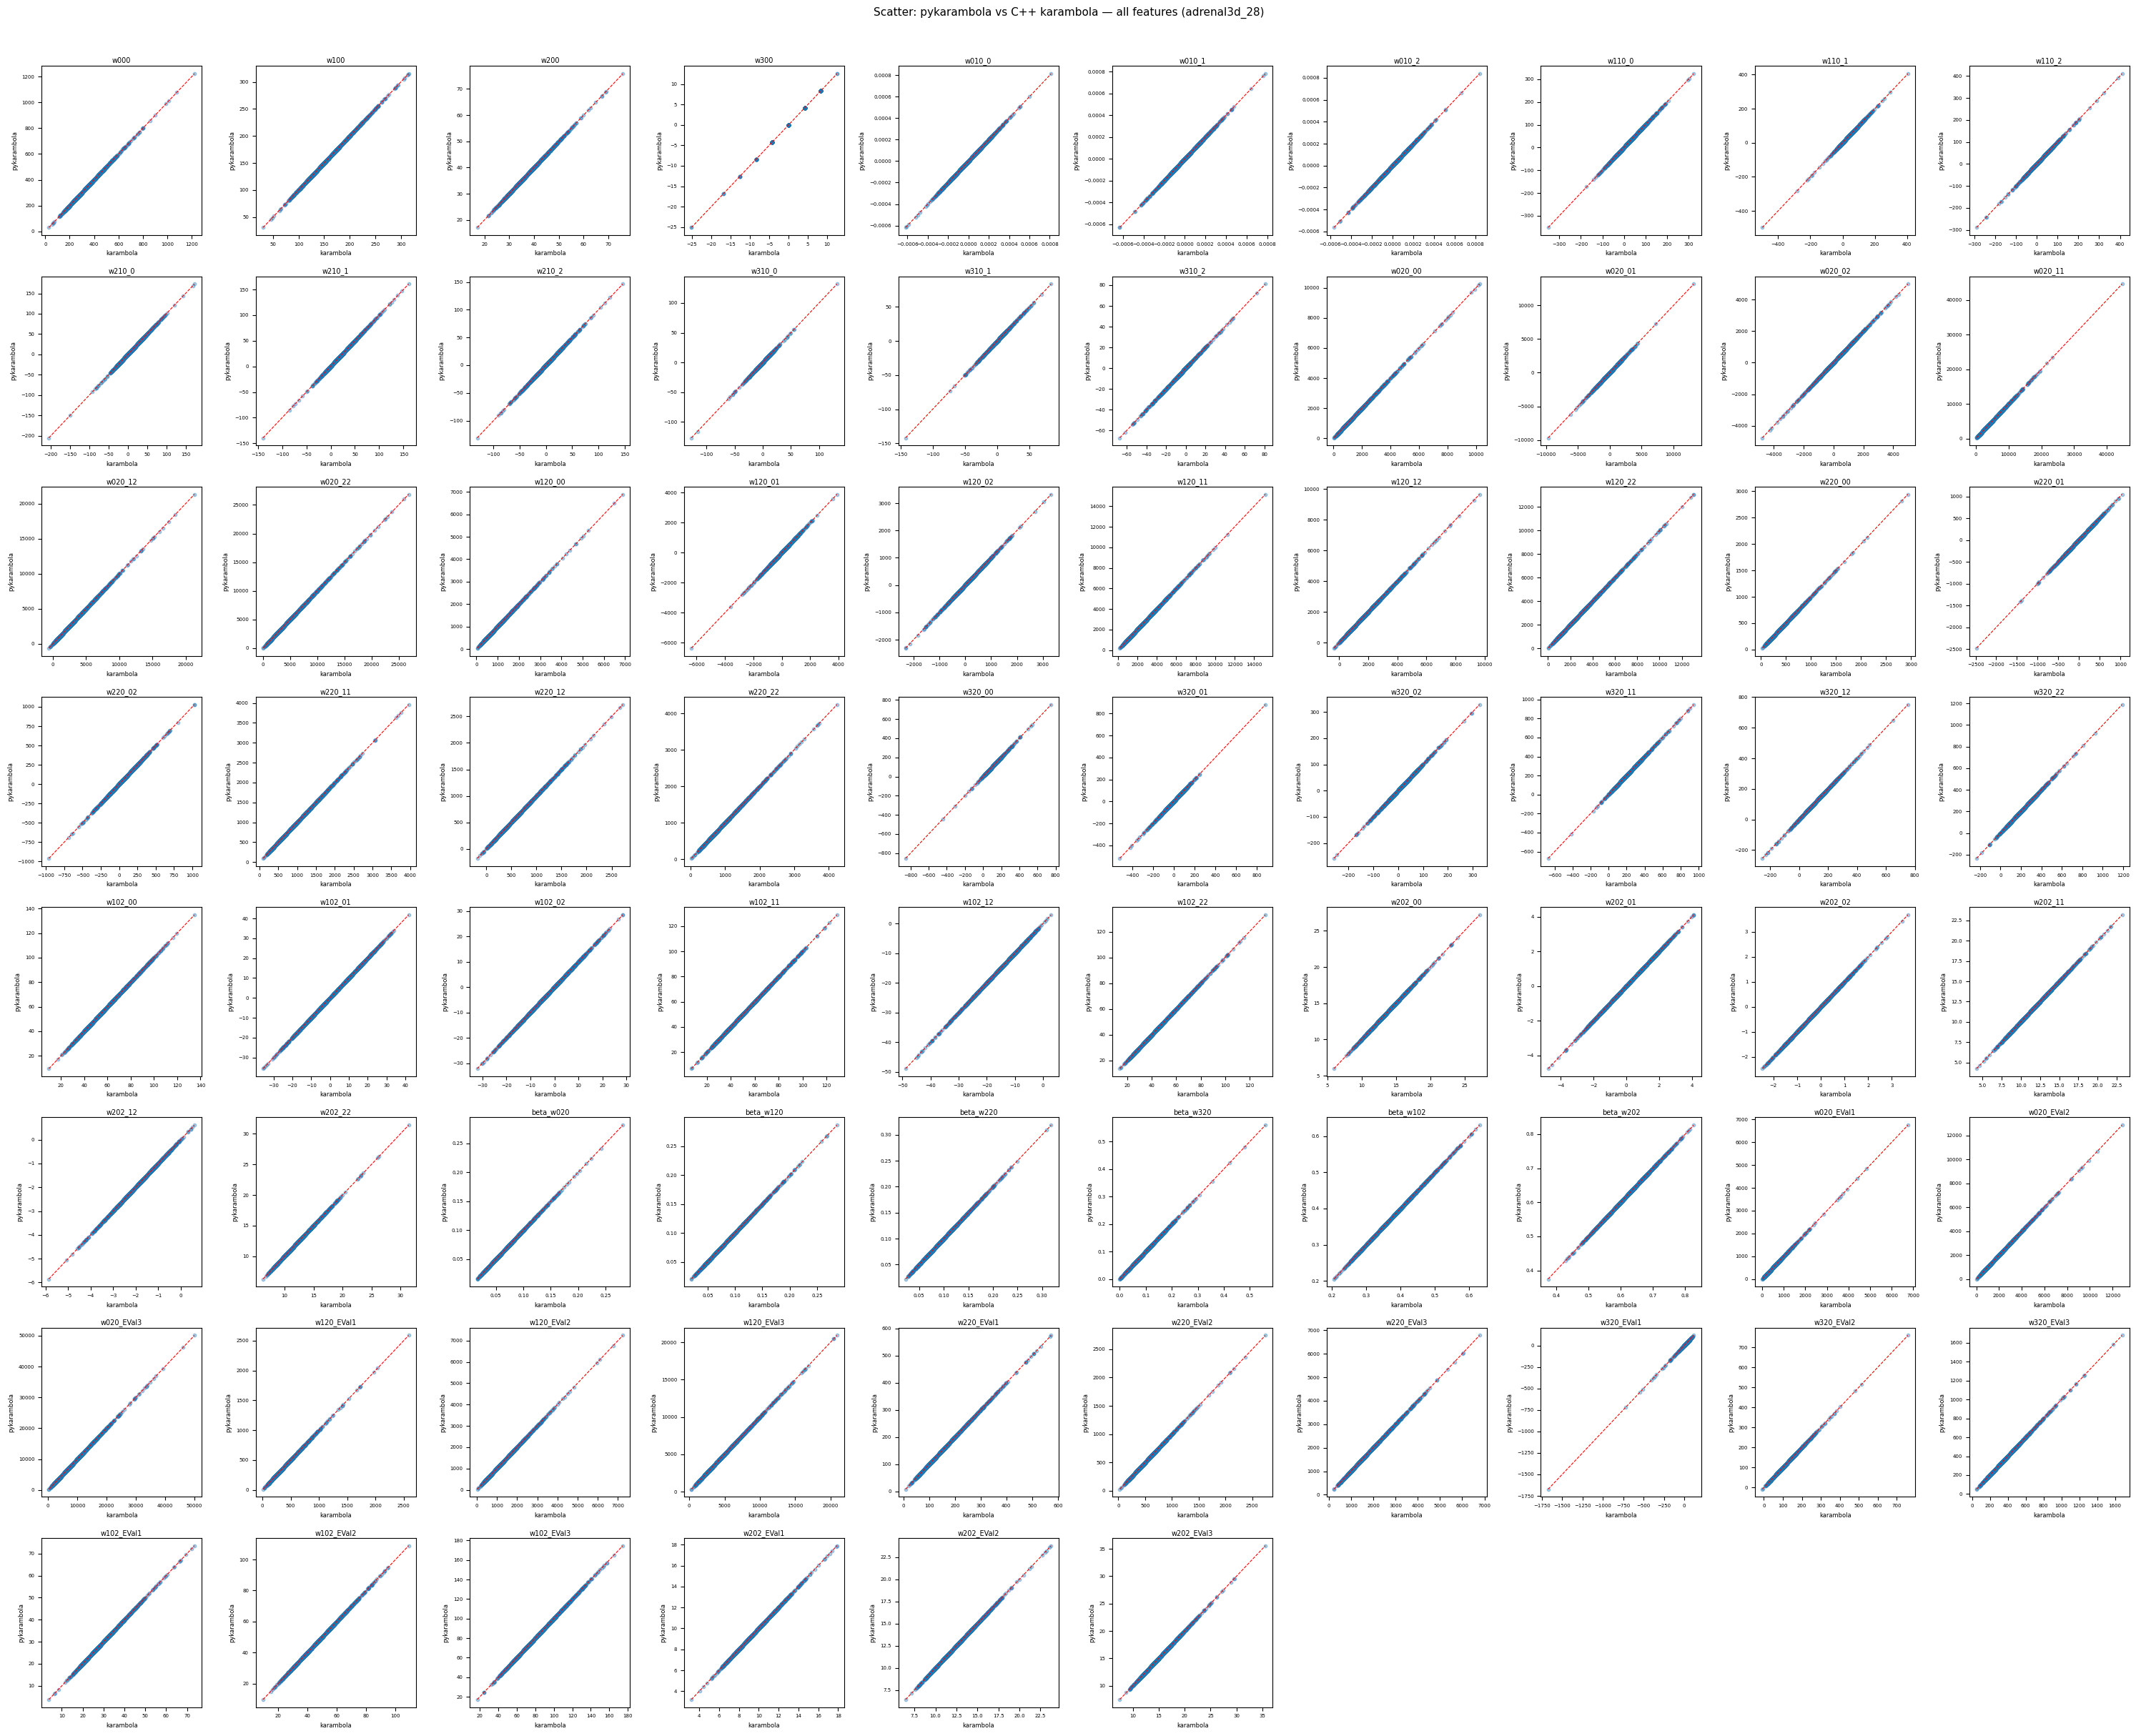

Saved → results/scatter_all_features_64.pdf


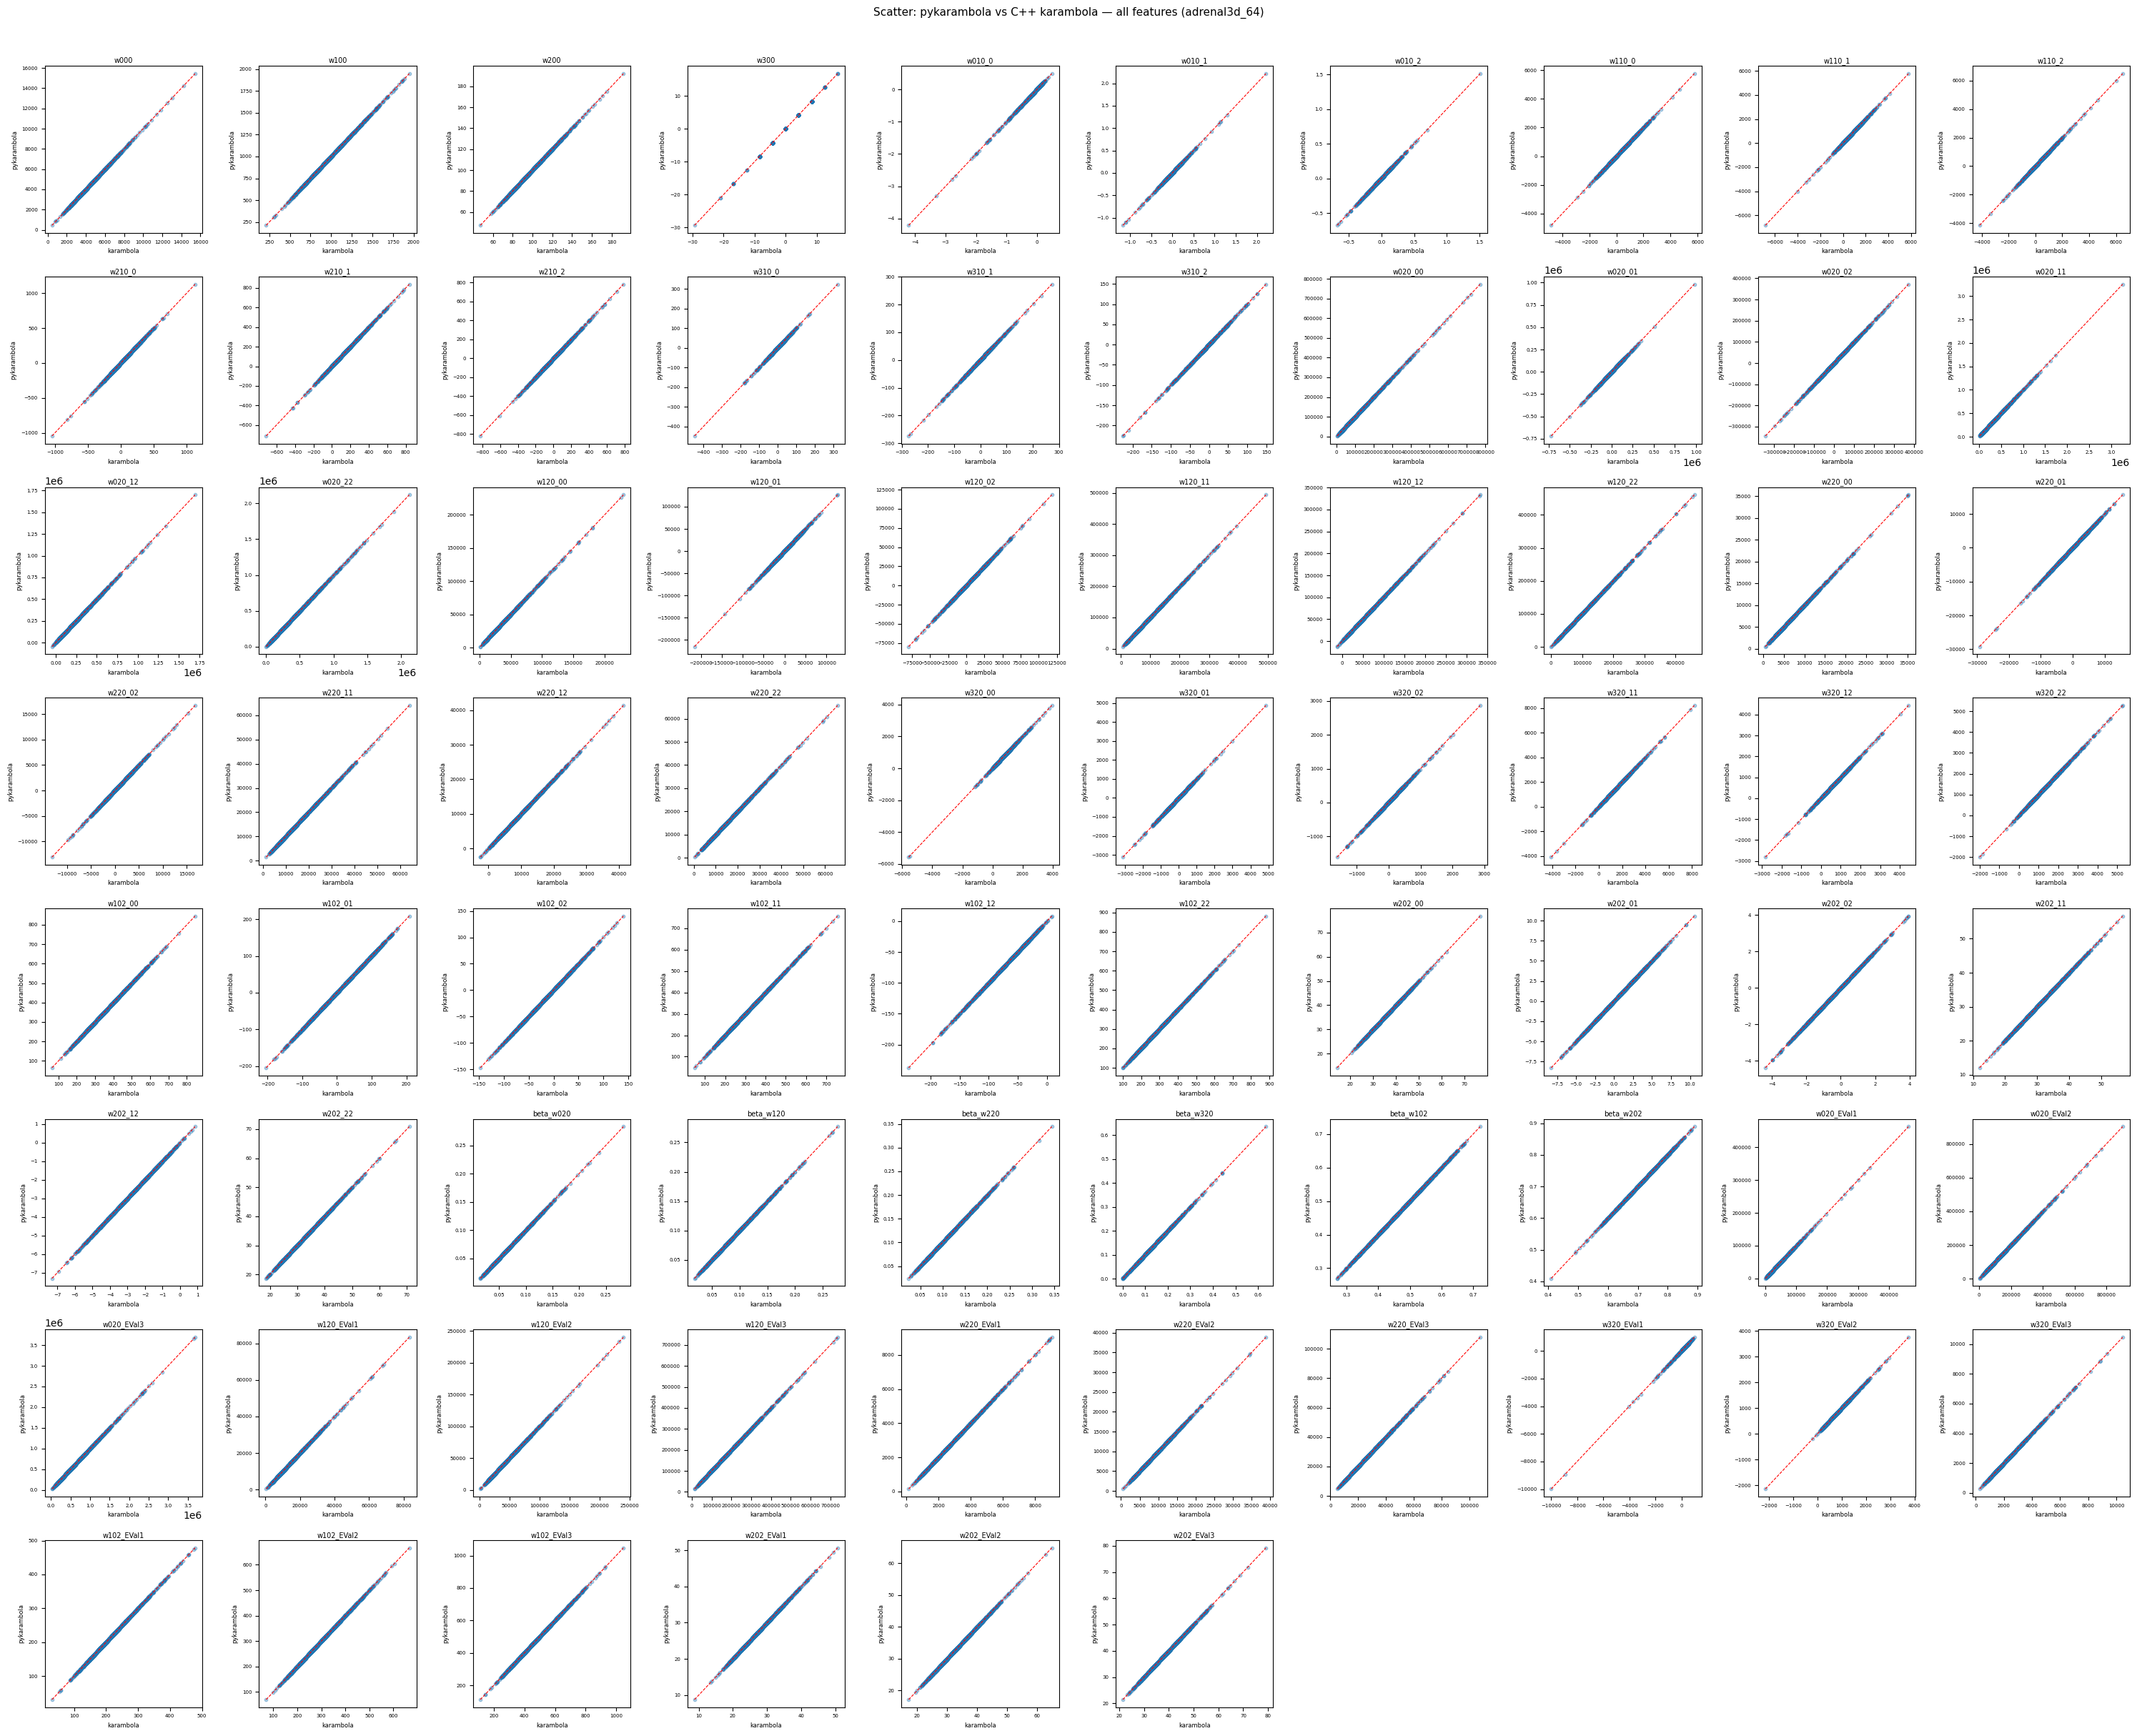

In [70]:
all_features = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'beta_{t}' for t in TENSOR_KEYS]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)
# 4 scalars + 12 vector components + 36 tensor elements (upper triangle, symmetric)
# + 6 betas + 18 eigenvalues = 76 features total

NCOLS = 10
NROWS = 8   # 10 × 8 = 80 slots ≥ 76

for channel in CHANNELS:
    df_m = merged[channel]

    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 3, NROWS * 3))
    axes = axes.flatten()

    for idx, feat in enumerate(all_features):
        ax = axes[idx]
        k_vals  = df_m[f'{feat}_k']
        py_vals = df_m[f'{feat}_py']
        ax.scatter(k_vals, py_vals, s=10, alpha=0.35, rasterized=True)
        lo = min(k_vals.min(), py_vals.min())
        hi = max(k_vals.max(), py_vals.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=0.8)
        ax.set_title(feat, fontsize=7, pad=3)
        ax.set_xlabel('karambola', fontsize=6)
        ax.set_ylabel('pykarambola', fontsize=6)
        ax.tick_params(labelsize=5)

    # Hide any unused axes
    for idx in range(len(all_features), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'Scatter: pykarambola vs C++ karambola — all features (adrenal3d_{channel})',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'scatter_all_features_{channel}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()

### Figure 2 — Bar chart: mean relative error per functional

Saved → results/bar_mean_relative_error.pdf


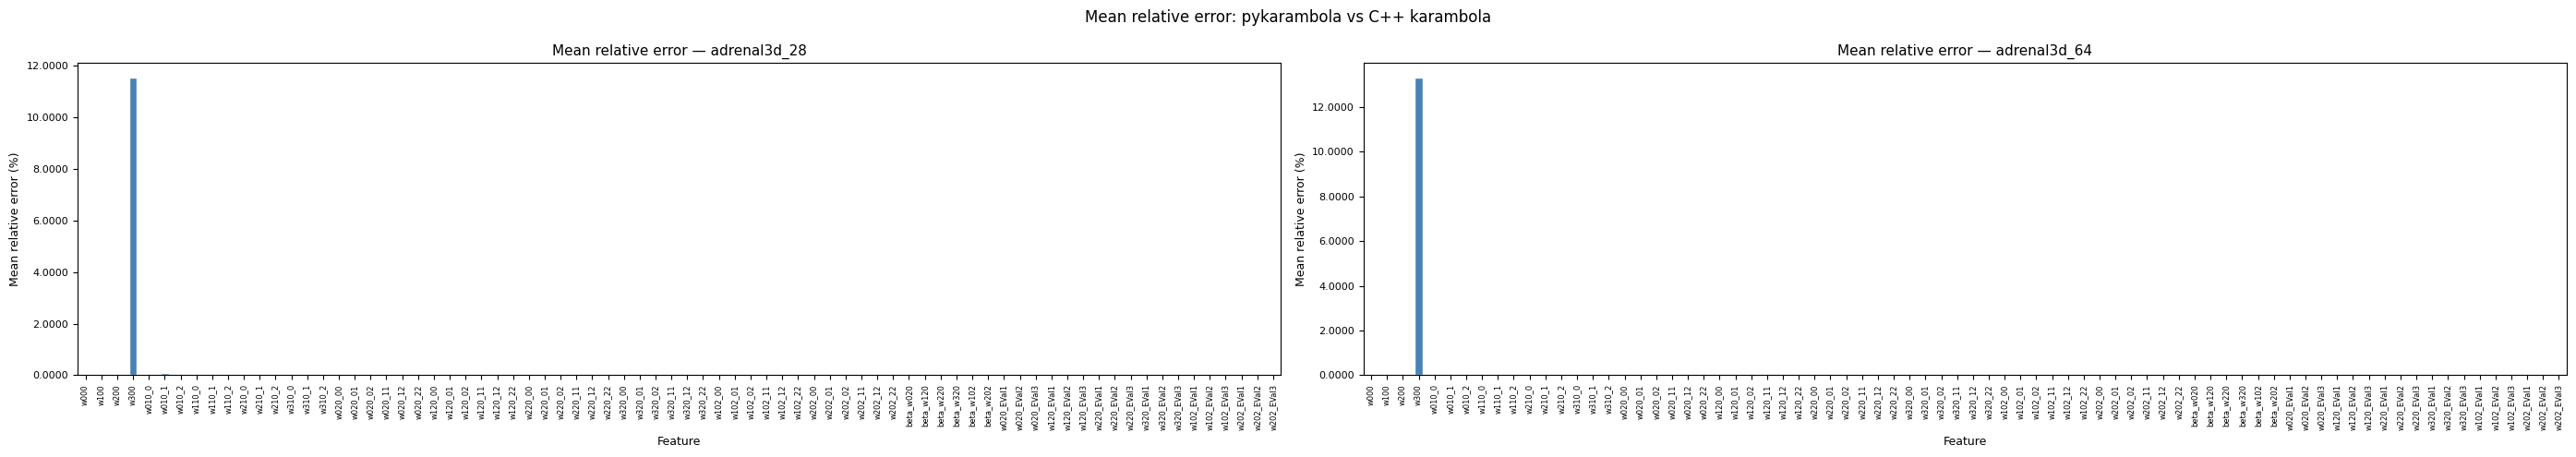

In [71]:
compare_cols = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'beta_{t}' for t in TENSOR_KEYS]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)

fig, axes = plt.subplots(1, 2, figsize=(28, 5), sharey=False)

for ax, channel in zip(axes, CHANNELS):
    df_m = merged[channel]
    summary = error_summary(df_m, compare_cols)

    summary['mean_rel_err_%'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Mean relative error — adrenal3d_{channel}', fontsize=11)
    ax.set_xlabel('Feature', fontsize=9)
    ax.set_ylabel('Mean relative error (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.suptitle('Mean relative error: pykarambola vs C++ karambola', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(FIGURES_PATH, 'bar_mean_relative_error.pdf')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved → {fig_path}')
plt.show()

### Table — max and mean relative error per functional

In [72]:
for channel in CHANNELS:
    df_m = merged[channel]
    summary = error_summary(df_m, compare_cols)
    print(f'\n=== adrenal3d_{channel} ===')
    print(summary.to_string(float_format='{:.6f}'.format))
    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_error_summary.csv')
    summary.to_csv(csv_path)
    print(f'Saved → {csv_path}')


=== adrenal3d_28 ===
            mean_rel_err_%  max_rel_err_%
feature                                  
w000              0.000000       0.000000
w100              0.000000       0.000000
w200              0.000001       0.000002
w300             11.512561     192.155172
w010_0            0.029985      30.564784
w010_1            0.094697     150.000000
w010_2            0.000000       0.000034
w110_0            0.000000       0.000000
w110_1            0.000000       0.000000
w110_2            0.000000       0.000000
w210_0            0.000003       0.000668
w210_1            0.000008       0.001876
w210_2            0.000014       0.003523
w310_0            0.000000       0.000000
w310_1            0.000000       0.000000
w310_2            0.000000       0.000000
w020_00           0.000000       0.000000
w020_01           0.000000       0.000000
w020_02           0.000000       0.000000
w020_11           0.000000       0.000000
w020_12           0.000000       0.000000
w020_22     

### Figure 3 — Heatmap: mean relative error per shape label × feature

Saved → results/heatmap_relative_error_28.pdf


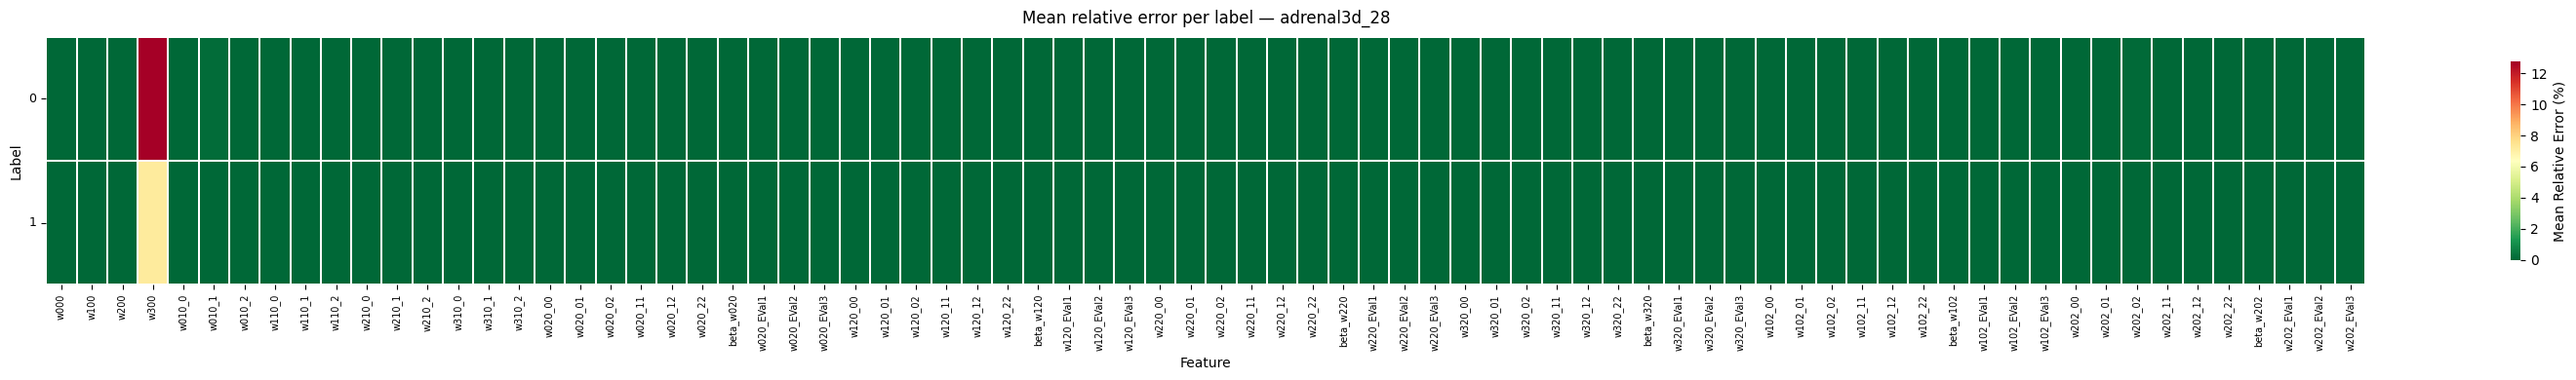

Saved → results/heatmap_relative_error_64.pdf


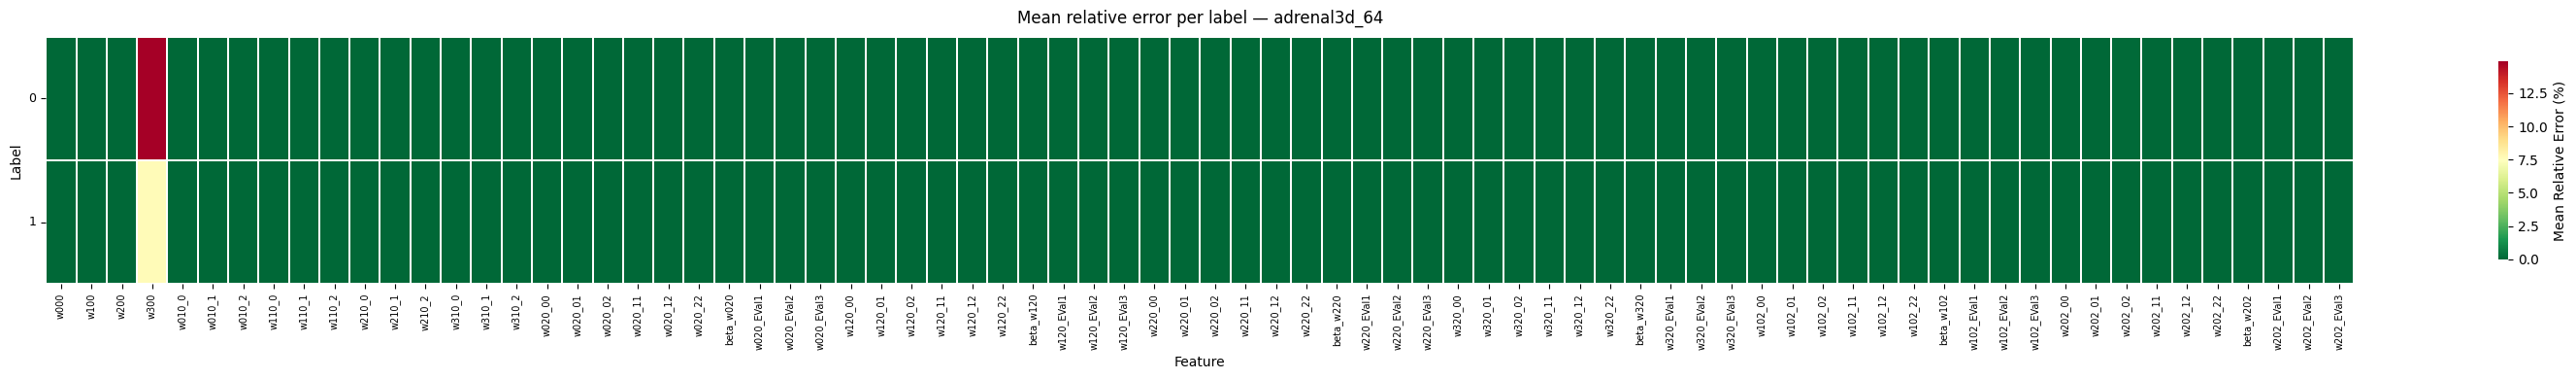

In [73]:
for channel in CHANNELS:
    df_m = merged[channel]
    numeric_cols = [c.replace('_k', '') for c in df_m.columns
                    if c.endswith('_k') and c.replace('_k', '') in compare_cols]

    heatmap_rows = []
    for lbl in sorted(df_m['label'].unique()):
        mask = df_m['label'] == lbl
        row = {'label': lbl}
        for col in numeric_cols:
            row[col] = relative_error_series(df_m[mask], col).mean()
        heatmap_rows.append(row)

    hmap_df = pd.DataFrame(heatmap_rows).set_index('label').fillna(0)

    fig, ax = plt.subplots(figsize=(max(14, len(hmap_df.columns) * 0.4), 4))
    seaborn.heatmap(
        hmap_df, annot=False, cmap='RdYlGn_r', linewidths=0.2, ax=ax,
        cbar_kws={'label': 'Mean Relative Error (%)', 'shrink': 0.8}
    )
    ax.set_title(f'Mean relative error per label — adrenal3d_{channel}',
                 fontsize=12, pad=10)
    ax.set_xlabel('Feature', fontsize=10)
    ax.set_ylabel('Label',   fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'heatmap_relative_error_{channel}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()

### Top relative error cases in w202_02

In [60]:
col = 'w202_02'  # ← change this to any component

for channel in CHANNELS:
    df_k = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_p = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    # merge on keys to guarantee row alignment
    df = df_k.merge(df_p, on=['image_num', 'label', 'subfolder'], suffixes=('_k', '_p'))

    rel_error = (df[f'{col}_p'] - df[f'{col}_k']).abs() / df[f'{col}_k'].abs()

    print(f"\n=== adrenal3d_{channel} — top 5 max relative error per label for {col} ===")
    for label in [0, 1]:
        mask = df['label'] == label
        rel_label = rel_error[mask].rename(col).to_frame()
        rel_label['image_num'] = df[mask]['image_num'].values
        rel_label['subfolder'] = df[mask]['subfolder'].values
        rel_label[f'k_{col}'] = df[mask][f'{col}_k'].values
        rel_label[f'p_{col}'] = df[mask][f'{col}_p'].values

        top5 = rel_label.nlargest(5, col)
        print(f"\n  Label {label}:")
        for _, row in top5.iterrows():
            print(f"    image_num={int(row['image_num'])}, subfolder={row['subfolder']}: rel_err={row[col]:.5g} | karambola={row[f'k_{col}']:.5g}, pykarambola={row[f'p_{col}']:.5g}")


=== adrenal3d_28 — top 5 max relative error per label for w202_02 ===

  Label 0:
    image_num=198, subfolder=train: rel_err=21.342 | karambola=-4.2852e-10, pykarambola=8.717e-09
    image_num=330, subfolder=train: rel_err=5.1096e-05 | karambola=0.00016858, pykarambola=0.00016859
    image_num=562, subfolder=train: rel_err=8.8969e-06 | karambola=0.0047763, pykarambola=0.0047764
    image_num=854, subfolder=train: rel_err=4.3397e-06 | karambola=-0.0021695, pykarambola=-0.0021695
    image_num=80, subfolder=validation: rel_err=3.3448e-06 | karambola=0.010341, pykarambola=0.010341

  Label 1:
    image_num=61, subfolder=validation: rel_err=3.563e-06 | karambola=0.0037827, pykarambola=0.0037827
    image_num=653, subfolder=train: rel_err=1.8468e-06 | karambola=-0.042001, pykarambola=-0.042001
    image_num=33, subfolder=validation: rel_err=1.7355e-06 | karambola=0.011803, pykarambola=0.011803
    image_num=37, subfolder=train: rel_err=1.5456e-06 | karambola=-0.0017818, pykarambola=-0.001

### Top relative error in w300

In [75]:
col = 'w300'  # ← change this to any component

for channel in CHANNELS:
    df_k = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_p = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    # merge on keys to guarantee row alignment
    df = df_k.merge(df_p, on=['image_num', 'label', 'subfolder'], suffixes=('_k', '_p'))

    rel_error = (df[f'{col}_p'] - df[f'{col}_k']).abs() / df[f'{col}_k'].abs()

    print(f"\n=== adrenal3d_{channel} — top 5 max relative error per label for {col} ===")
    for label in [0, 1]:
        mask = df['label'] == label
        rel_label = rel_error[mask].rename(col).to_frame()
        rel_label['image_num'] = df[mask]['image_num'].values
        rel_label['subfolder'] = df[mask]['subfolder'].values
        rel_label[f'k_{col}'] = df[mask][f'{col}_k'].values
        rel_label[f'p_{col}'] = df[mask][f'{col}_p'].values

        top5 = rel_label.nlargest(5, col)
        print(f"\n  Label {label}:")
        for _, row in top5.iterrows():
            print(f"    image_num={int(row['image_num'])}, subfolder={row['subfolder']}: rel_err={row[col]:.5g} | karambola={row[f'k_{col}']:.5g}, pykarambola={row[f'p_{col}']:.5g}")


=== adrenal3d_28 — top 5 max relative error per label for w300 ===

  Label 0:
    image_num=1009, subfolder=train: rel_err=115.36 | karambola=1.5266e-16, pykarambola=1.7764e-14
    image_num=826, subfolder=train: rel_err=51.581 | karambola=-4.3021e-16, pykarambola=2.176e-14
    image_num=773, subfolder=train: rel_err=37.8 | karambola=2.7756e-16, pykarambola=-1.0214e-14
    image_num=1021, subfolder=train: rel_err=23.085 | karambola=-9.8532e-16, pykarambola=2.176e-14
    image_num=24, subfolder=validation: rel_err=15 | karambola=-2.498e-16, pykarambola=-3.9968e-15

  Label 1:
    image_num=297, subfolder=train: rel_err=6.1262 | karambola=-1.4294e-15, pykarambola=7.3275e-15
    image_num=649, subfolder=train: rel_err=2.2053 | karambola=7.3691e-15, pykarambola=-8.8818e-15
    image_num=904, subfolder=train: rel_err=2.1089 | karambola=-1.9623e-14, pykarambola=2.176e-14
    image_num=1025, subfolder=train: rel_err=1.7548 | karambola=-1.0075e-14, pykarambola=-2.7756e-14
    image_num=1144,

### Average and std w202 tensor components per label (C++ karambola)

In [61]:
for channel in CHANNELS:
    df_k = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_p = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    print(f"\n=== adrenal3d_{channel} — w202_02 stats ===")
    for label in [0, 1]:
        mask_k = df_k['label'] == label
        mask_p = df_p['label'] == label
        k = df_k[mask_k]['w202_02']
        p = df_p[mask_p]['w202_02']
        print(f"\n  Label {label}:")
        print(f"    karambola:    mean={k.mean():.6f} ± {k.std():.6f}, median={k.median():.6f}")
        print(f"    pykarambola:  mean={p.mean():.6f} ± {p.std():.6f}, median={p.median():.6f}")


=== adrenal3d_28 — w202_02 stats ===

  Label 0:
    karambola:    mean=-0.344338 ± 0.852264, median=-0.412485
    pykarambola:  mean=-0.344338 ± 0.852265, median=-0.412485

  Label 1:
    karambola:    mean=-0.049697 ± 0.759600, median=-0.007146
    pykarambola:  mean=-0.049697 ± 0.759600, median=-0.007146

=== adrenal3d_64 — w202_02 stats ===

  Label 0:
    karambola:    mean=-0.512759 ± 1.201831, median=-0.581406
    pykarambola:  mean=-0.512759 ± 1.201831, median=-0.581406

  Label 1:
    karambola:    mean=-0.162247 ± 1.066653, median=-0.174030
    pykarambola:  mean=-0.162247 ± 1.066653, median=-0.174030


### Mean, std and abs min for all columns

In [65]:
for channel in CHANNELS:
    df_k = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_p = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    print(f"\n=== adrenal3d_{channel} ===")
    for label in [0, 1]:
        mask_k = df_k['label'] == label
        mask_p = df_p['label'] == label

        mean_k = df_k[mask_k][compare_cols].mean()
        std_k  = df_k[mask_k][compare_cols].std()
        mean_p = df_p[mask_p][compare_cols].mean()
        std_p  = df_p[mask_p][compare_cols].std()

        print(f"\n  Label {label}:")
        min_k  = df_k[mask_k][compare_cols].abs().min()
        min_p  = df_p[mask_p][compare_cols].abs().min()

        for col in compare_cols:
            print(f"    {col}: karambola={mean_k[col]:.5g} ± {std_k[col]:.5g} (min={min_k[col]:.5g})  |  pykarambola={mean_p[col]:.5g} ± {std_p[col]:.5g} (min={min_p[col]:.5g})")

        # top 5 closest to zero by karambola mean
        top5_zero_k = mean_k.abs().nsmallest(5)
        print(f"\n  Top 5 closest to zero (karambola, label {label}):")
        for col, val in top5_zero_k.items():
            print(f"    {col}: karambola={mean_k[col]:.5g} ± {std_k[col]:.5g}  |  pykarambola={mean_p[col]:.5g} ± {std_p[col]:.5g}")


=== adrenal3d_28 ===

  Label 0:
    w000: karambola=312.48 ± 95.361 (min=29.375)  |  pykarambola=312.48 ± 95.361 (min=29.375)
    w100: karambola=152.88 ± 37.465 (min=30.716)  |  pykarambola=152.88 ± 37.465 (min=30.716)
    w200: karambola=37.431 ± 6.5302 (min=17.137)  |  pykarambola=37.431 ± 6.5302 (min=17.137)
    w300: karambola=3.1026 ± 3.1854 (min=1.5266e-16)  |  pykarambola=3.1026 ± 3.1854 (min=0)
    w010_0: karambola=-4.0488e-06 ± 0.00013341 (min=1.8563e-13)  |  pykarambola=-4.0488e-06 ± 0.00013341 (min=2.6734e-13)
    w010_1: karambola=-6.0227e-06 ± 0.00012952 (min=2.1316e-14)  |  pykarambola=-6.0227e-06 ± 0.00012952 (min=4.2633e-14)
    w010_2: karambola=-1.2036e-06 ± 0.00012493 (min=1.9096e-13)  |  pykarambola=-1.2036e-06 ± 0.00012493 (min=1.9096e-13)
    w110_0: karambola=10.887 ± 52.086 (min=0.038292)  |  pykarambola=10.887 ± 52.086 (min=0.038292)
    w110_1: karambola=36.007 ± 40.476 (min=0.082199)  |  pykarambola=36.007 ± 40.476 (min=0.082199)
    w110_2: karambola=10.

`w300` and `w202_02` min are the smallest, which explains the high mean relative error. 

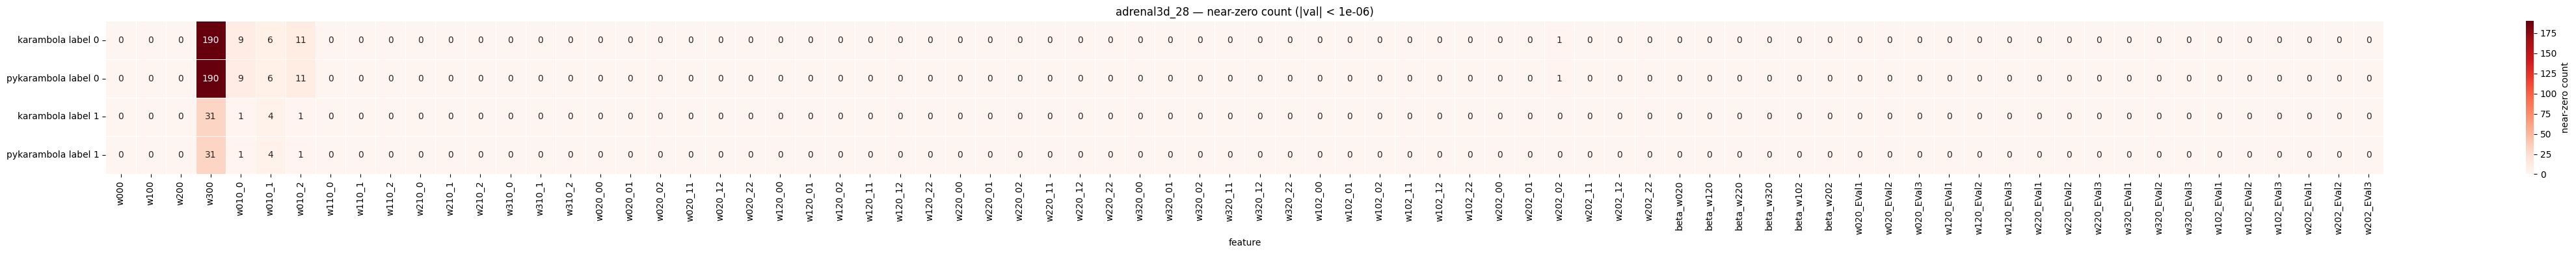

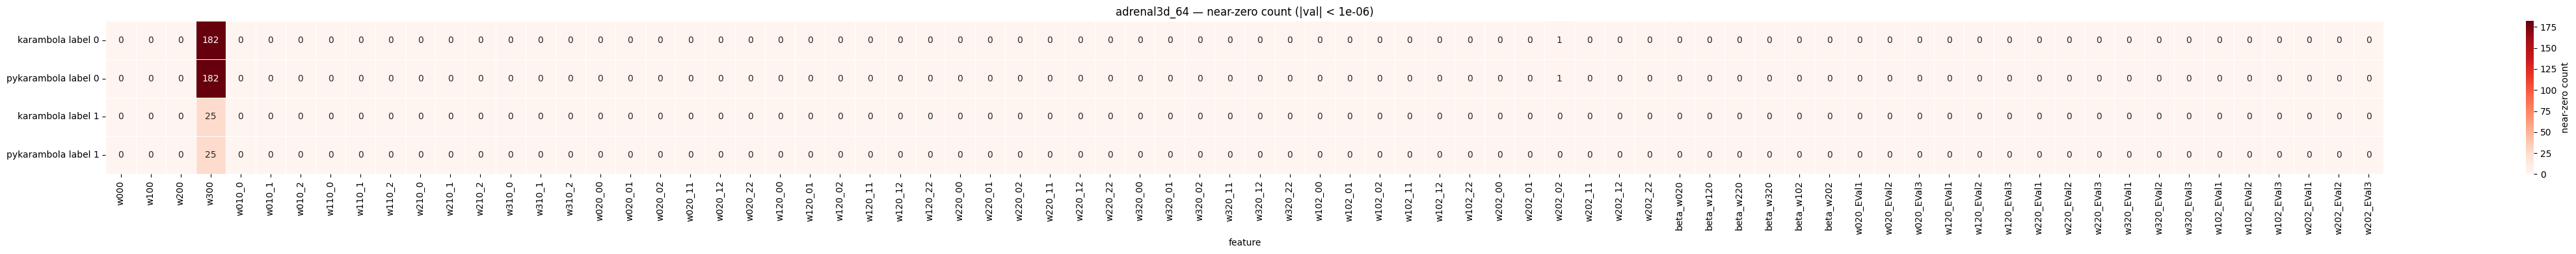

In [74]:
import seaborn as sns
threshold = 1e-6

for channel in CHANNELS:
    df_k = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    df_p = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv'))

    rows = {}
    for label in [0, 1]:
        mask_k = df_k['label'] == label
        mask_p = df_p['label'] == label
        rows[f'karambola label {label}']    = (df_k[mask_k][compare_cols].abs() < threshold).sum()
        rows[f'pykarambola label {label}']  = (df_p[mask_p][compare_cols].abs() < threshold).sum()

    heat_df = pd.DataFrame(rows).T  # rows = tool+label, cols = features

    fig, ax = plt.subplots(figsize=(max(12, len(compare_cols) * 0.6), 4))
    sns.heatmap(heat_df, annot=True, fmt='d', cmap='Reds', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'near-zero count'})
    ax.set_title(f'adrenal3d_{channel} — near-zero count (|val| < {threshold})')
    ax.set_xlabel('feature')
    ax.set_ylabel('')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_OUT_PATH, f'adrenal3d_{channel}', 'near_zero_heatmap.png'), dpi=150)
    plt.show()

`w300` also has a large amount of 0s. `w202_2` also has that 1 very small value close to 0 that provides the large error. 